# Visual walkthrough: a whole-slide image → features (cloud-direct)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CraigMyles/raw2features/blob/main/notebooks/02_visual_walkthrough.ipynb)

This notebook runs the whole pipeline **straight against a public slide in the cloud -
nothing is downloaded** - and *shows* each step on a real H&E section:

1. **Find** a slide in the [BioImage Archive](https://www.ebi.ac.uk/bioimage-archive/)
   (the [SurGen](https://www.ebi.ac.uk/biostudies/studies/S-BIAD1285) study - 1,020
   H&E colorectal WSIs), resolving its OME-Zarr URL from the public S3 bucket.
2. **See** the whole slide as a thumbnail.
3. **Segment** the tissue and lay down the patch grid.
4. **Sample** a few patches the model will actually see.
5. **Extract** ResNet-50 features and visualise them as a map of the slide.

CPU-only, no GPU, no login token.

In [1]:
# Bootstrap: works on Colab and a local install.
import importlib.util, subprocess, sys

IN_COLAB = "google.colab" in sys.modules
HAVE_PKG = importlib.util.find_spec("raw2features") is not None

EXTRAS = "zarr,image,torch,models"
SPEC = f"raw2features[{EXTRAS}]"  # PyPI; pin a version (==0.1.0) for reproducibility
if IN_COLAB or not HAVE_PKG:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", SPEC])

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import raw2features

mpl.rcParams["figure.dpi"] = 72   # keep embedded figures light for git/GitHub viewing
print("raw2features", raw2features.__version__, "| python", sys.version.split()[0])

raw2features 0.1.0 | python 3.12.3


## 1. Find a slide in the BioImage Archive

The [BioImage Archive](https://www.ebi.ac.uk/bioimage-archive/) (BIA) converts deposited
slides to **OME-Zarr** and serves them from public fast storage. We resolve a current URI
from the storage listing rather than hard-coding one, since the per-image UUIDs change
between depositions.

> **Note on stability.** BIA treats these OME-Zarr copies as an *access service*, not
> the long-term preservation copy: the storage location and URLs **may change over time**
> (only the accession, `S-BIAD1285`, is permanent). BIA's guidance is to fetch current
> OME-Zarr URIs through their **API**; a public endpoint for that is still rolling out, so
> for now we resolve from the public storage layout and fall back to the
> [study page](https://www.ebi.ac.uk/biostudies/studies/S-BIAD1285) if it shifts. Once the
> BIA API is generally available, this cell should use it instead.

In [2]:
import urllib.request
import xml.etree.ElementTree as ET

BIA_S3 = "https://uk1s3.embassy.ebi.ac.uk/bia-integrator-data"
ACCESSION = "S-BIAD1285"   # SurGen: 1,020 H&E WSIs (Myles et al.), doi:10.6019/S-BIAD1285
_NS = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}

def _common_prefixes(prefix):
    """One delimited S3 listing -> the immediate sub-'folders' under `prefix`."""
    url = f"{BIA_S3}?list-type=2&prefix={prefix}&delimiter=/"
    root = ET.fromstring(urllib.request.urlopen(url, timeout=60).read())
    return [p.text for p in root.findall(".//s3:CommonPrefixes/s3:Prefix", _NS)]

def resolve_ome_zarr(accession):
    """Find a current OME-Zarr URI for an accession from BIA's public storage.

    BIA treats OME-Zarr on fast storage as an access service, so the layout/URLs can change
    over time (only the accession is permanent). If this stops resolving, fetch a current
    URI from the study page and assign it to URL directly. Layout today is
    <accession>/<image-uuid>/<rep-uuid>.ome.zarr/ ; we return the first match.
    """
    study_page = f"https://www.ebi.ac.uk/biostudies/studies/{accession}"
    try:
        for image_prefix in _common_prefixes(f"{accession}/"):
            for rep in _common_prefixes(image_prefix):
                if rep.rstrip("/").endswith(".ome.zarr"):
                    return f"{BIA_S3}/{rep.rstrip('/')}"
    except Exception as exc:
        raise RuntimeError(
            f"could not list BIA storage for {accession} ({exc}); the layout may have "
            f"changed - get a current OME-Zarr URI from {study_page}"
        ) from exc
    raise RuntimeError(f"no OME-Zarr found under {accession} - see {study_page}")

URL = resolve_ome_zarr(ACCESSION)
print("resolved OME-Zarr:\n ", URL)

resolved OME-Zarr:
  https://uk1s3.embassy.ebi.ac.uk/bia-integrator-data/S-BIAD1285/449c127b-fccd-4bfa-b72d-f6f7f66ef2ed/b2f711e1-8088-4d67-937e-2ff20e2f89d2.ome.zarr


## 2. See the whole slide

Open the slide **without downloading it** and read a coarse pyramid level for a
thumbnail. Whole-slide images are pyramids - here level 0 is gigapixel-scale, and we
grab a small level for a quick look.

level 0: 162,914 x 103,650 px   |   0.1112 µm/px   |   11 pyramid levels


thumbnail read from level 7: 1272 x 809 px


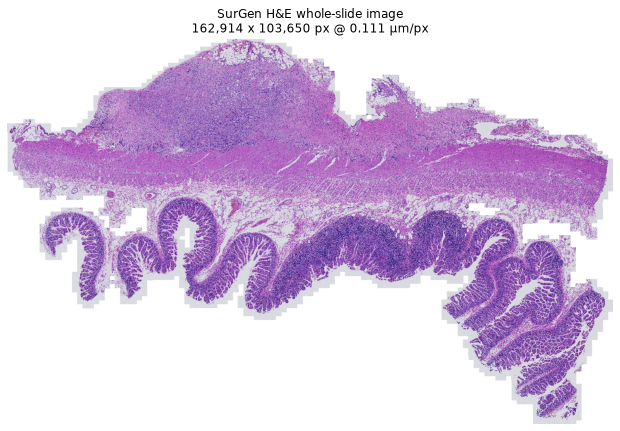

In [3]:
from raw2features.core.geometry import Point, Region, Size
from raw2features.readers.omezarr import OmeZarrReader

reader = OmeZarrReader(URL).open()   # keep it open for the rest of the notebook

w0, h0 = reader.level_dimensions[0]
print(f"level 0: {w0:,} x {h0:,} px   |   {reader.mpp:.4f} µm/px   |   "
      f"{len(reader.level_dimensions)} pyramid levels")

# Pick the smallest level whose largest side is still >= 900 px for a crisp thumbnail.
thumb_level = max(
    i for i, s in enumerate(reader.level_dimensions) if max(s.width, s.height) >= 900
)
tw, th = reader.level_dimensions[thumb_level]
thumb = reader.read_region(Region(level=thumb_level, location=Point(0, 0),
                                  size=Size(tw, th)))
print(f"thumbnail read from level {thumb_level}: {thumb.shape[1]} x {thumb.shape[0]} px")

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(thumb)
ax.set_title(f"SurGen H&E whole-slide image\n{w0:,} x {h0:,} px @ {reader.mpp:.3f} µm/px")
ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Segment the tissue, lay down the patch grid

`raw2features` runs Otsu tissue segmentation and tiles the tissue into a regular grid at
the requested micron-per-pixel. The built-in `thumbnail --overlay` renders both for us:
the **tissue tint** is the segmentation mask, the **green grid** is the kept patches -
background is skipped, so the model only sees tissue.

plain: b2f711e1-8088-4d67-937e-2ff20e2f89d2.thumbnail.png
overlay: b2f711e1-8088-4d67-937e-2ff20e2f89d2.thumbnail.overlay.png
mpp: 8.0
max_px: None
read_level: 6
downsample: 64.0
size_wh: [2545, 1619]


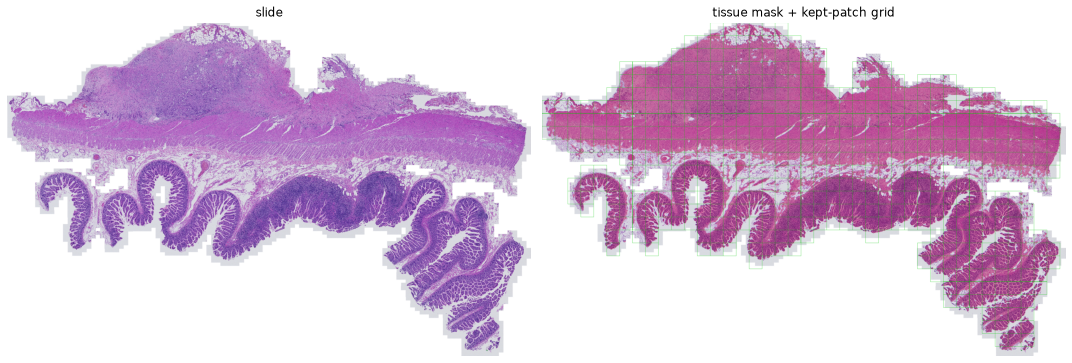

In [4]:
import os, glob, tempfile

WORK = tempfile.mkdtemp(prefix="r2f_viz_")
MPP, PATCH, MODEL = 2.0, 224, "resnet50"   # 2 µm/px (~5x) keeps the demo fast on CPU

subprocess.check_call([
    "raw2features", "thumbnail", URL, WORK + "/",
    "--overlay", "--thumbnail-mpp", "8.0",
    "--mpp", str(MPP), "--patch-size", str(PATCH),  # match the embed geometry
])
overlay_png = glob.glob(os.path.join(WORK, "*.thumbnail.overlay.png"))[0]
plain_png = glob.glob(os.path.join(WORK, "*.thumbnail.png"))[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, png, title in [(axes[0], plain_png, "slide"),
                       (axes[1], overlay_png, "tissue mask + kept-patch grid")]:
    ax.imshow(plt.imread(png)); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Extract features (cloud-direct, no download)

Now embed the slide: segment → tile at exactly 2 µm/px → ResNet-50 on each patch. Every
read streams from S3; nothing lands on disk except the compact embeddings store. On a
laptop CPU this is a few hundred patches in well under a minute.

In [5]:
slide_id = URL.rstrip("/").split("/")[-1].replace(".ome.zarr", "")
out_dir = os.path.join(WORK, "out")

subprocess.check_call([
    "raw2features", "embed", URL, out_dir + "/",
    "-m", MODEL, "--mpp", str(MPP), "--patch-size", str(PATCH),
    "--device", "cpu", "--read-block", "8",
])

from raw2features.core.store import open_grid  # selects the single grid (grids/<mpp>_<px>/)
store = os.path.join(out_dir, f"{slide_id}.embeddings.zarr")
g = open_grid(store)
coords = g["coords"][:]                      # (N, 2) int32 level-0 (x, y) per patch
feats = g["features"][MODEL][:].astype(np.float32)   # (N, dim), 1:1 with coords
level0_patch = g.attrs["raw2features"]["patching"]["level0_patch"]
print(f"{coords.shape[0]} patches  ->  {feats.shape[1]}-d ResNet-50 features each")

slide_id: b2f711e1-8088-4d67-937e-2ff20e2f89d2
status: complete
grids: {'mpp2_px224': ['resnet50']}
output_uri: file:///tmp/r2f_viz_k37wdety/out/b2f711e1-8088-4d67-937e-2ff20e2f89d2.embeddings.zarr
per_grid: [{'slide_id': 'b2f711e1-8088-4d67-937e-2ff20e2f89d2', 'status': 'complete', 'n_patches': 536, 'models': ['resnet50'], 'models_added': ['resnet50'], 'models_skipped': [], 'slide_embeddings': {}, 'output_uri': 'file:///tmp/r2f_viz_k37wdety/out/b2f711e1-8088-4d67-937e-2ff20e2f89d2.embeddings.zarr', 'geojson': None, 'thumbnail': None, 'elapsed_s': 15.06}]
elapsed_s: 15.59


536 patches  ->  2048-d ResNet-50 features each


## 5. The patches the model sees

Each row of the feature matrix is one patch. Here are a handful, read back from the slide
at the exact coordinates and scale they were embedded at.

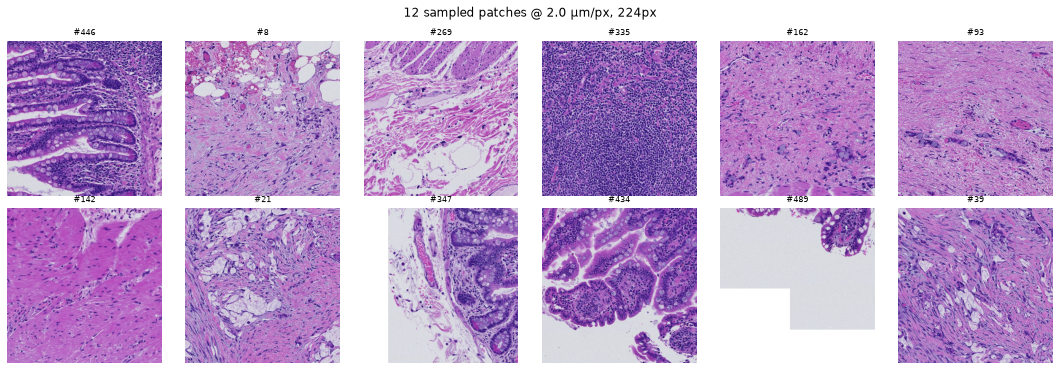

In [6]:
plan = reader.level_for_mpp(MPP, PATCH)   # which level + read size hits 2 µm/px exactly
rng = np.random.default_rng(0)
pick = rng.choice(coords.shape[0], size=min(12, coords.shape[0]), replace=False)

fig, axes = plt.subplots(2, 6, figsize=(15, 5.2))
for ax, idx in zip(axes.ravel(), pick):
    x, y = coords[idx]
    patch = reader.read_region(Region.patch(int(x), int(y), plan.read_px, plan.level))
    ax.imshow(patch); ax.set_title(f"#{idx}", fontsize=8); ax.axis("off")
for ax in axes.ravel()[len(pick):]:
    ax.axis("off")
fig.suptitle(f"{len(pick)} sampled patches @ {MPP} µm/px, {PATCH}px")
plt.tight_layout(); plt.show()

## 6. The model's view of the slide

These features encode tissue morphology. Project every patch's
1,000s-d vector to 3 dimensions (PCA) and paint each patch's grid cell with that colour:
**patches the model considers similar get similar colours**, so tumour, stroma, muscle and
mucosa separate out spatially - a "feature map" of the slide, built with no labels.

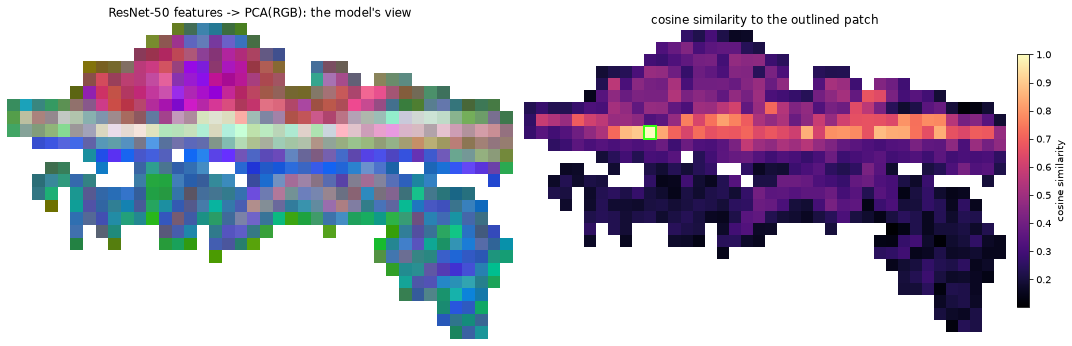

In [7]:
from matplotlib.patches import Rectangle

# Project every patch's feature vector to RGB via PCA (SVD, no sklearn): keep the top 3
# directions and scale them into colour channels.
X = feats - feats.mean(0)                             # centre the features
_, _, Vt = np.linalg.svd(X, full_matrices=False)      # rows of Vt are the principal directions
pc = X @ Vt[:3].T                                     # (N, 3): each patch in top-3 PC space
rgb = (pc - pc.min(0)) / (np.ptp(pc, axis=0) + 1e-9)  # scale each component to [0, 1]

# Cosine similarity of every patch to one reference patch.
ref = int(np.argmax(np.linalg.norm(pc, axis=1)))      # the patch furthest from average (distinctive)
unit = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9)  # unit-normalise each row,
sim = unit @ unit[ref]                                # so this dot product is cosine similarity

# Lay the patches back onto their grid cells (grid_index = row, col) so each map is an exact
# raster -- one pixel per patch -- letting us outline the reference cell precisely.
gi = g["grid_index"][:]
rows, cols = int(gi[:, 0].max()) + 1, int(gi[:, 1].max()) + 1
rgb_img = np.ones((rows, cols, 3))                    # white where there is no tissue
sim_img = np.full((rows, cols), np.nan)               # NaN cells render blank
rgb_img[gi[:, 0], gi[:, 1]] = rgb
sim_img[gi[:, 0], gi[:, 1]] = sim

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
axes[0].imshow(rgb_img, interpolation="nearest")
axes[0].set_title("ResNet-50 features -> PCA(RGB): the model's view")
sc = axes[1].imshow(sim_img, cmap="magma", interpolation="nearest")
axes[1].set_title("cosine similarity to the outlined patch")

# Outline the reference patch's cell. imshow centres pixel (row, col) on integer coords, so a
# cell spans +/- 0.5 -- hence the half-pixel offset on the box corner.
rr, cc = gi[ref]
axes[1].add_patch(Rectangle((cc - 0.5, rr - 0.5), 1, 1, fill=False,
                            edgecolor="#39ff14", linewidth=2.0))
for ax in axes:
    ax.set_aspect("equal"); ax.axis("off")
fig.colorbar(sc, ax=axes[1], fraction=0.025, pad=0.02, label="cosine similarity")
plt.tight_layout(); plt.show()

reader.close()                                        # done with the slide; release the reader

## What just happened

From one public URL, with nothing downloaded: slide -> tissue -> patches -> features -> a label-free map of the slide. The output is a compact, self-describing
`.embeddings.zarr` (see [`03_the_embeddings_store.ipynb`](03_the_embeddings_store.ipynb))
whose coordinates relocate every vector back onto the slide.

- Swap `MODEL` for a pathology foundation model (`uni`, `virchow2`, `gigapath`, …) - same
  pipeline, richer features (some need a Hugging Face token).
- This slide is OME-NGFF 0.4; raw2features reads the newer **0.5 / Zarr v3** identically
  - point it at any public 0.5 store (e.g. the EBI/IDR ome2024 conversions) and the same
  pipeline runs, no code change.
- Feed the features downstream: [`04_spatialdata.ipynb`](04_spatialdata.ipynb) exports to
  scverse SpatialData.

---
**[raw2features](https://github.com/CraigMyles/raw2features)** · OME-Zarr WSIs → foundation-model embeddings · author **Craig Myles** · licence **MIT**

If you use raw2features, please cite it ([`CITATION.cff`](https://github.com/CraigMyles/raw2features/blob/main/CITATION.cff)). Pretrained encoders carry their own licences ([`MODEL_LICENSES.md`](https://github.com/CraigMyles/raw2features/blob/main/docs/MODEL_LICENSES.md)).